In [1]:
# Malaria datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download(
    "iarunava/cell-images-for-detecting-malaria"
)

print(dataset_path)

/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria


In [2]:
# Dataset klasörlerini kontrol ediyoruz

import os

print(os.listdir(dataset_path))

['cell_images']


In [3]:
# Ana klasör içeriğini kontrol ediyoruz

base_path = dataset_path + "/cell_images"

print(os.listdir(base_path))

['Uninfected', 'Parasitized', 'cell_images']


In [4]:
# Infected klasöründeki örnek dosyaları kontrol ediyoruz

infected_path = base_path + "/Parasitized"

print(os.listdir(infected_path)[:5])

['C99P60ThinF_IMG_20150918_141001_cell_93.png', 'C99P60ThinF_IMG_20150918_141001_cell_133.png', 'C101P62ThinF_IMG_20150918_151942_cell_60.png', 'C162P123ThinF_IMG_20151116_102655_cell_163.png', 'C52P13thinF_IMG_20150725_124830_cell_174.png']


In [5]:
# Uninfected klasöründeki örnek dosyaları kontrol ediyoruz

uninfected_path = base_path + "/Uninfected"

print(os.listdir(uninfected_path)[:5])

['C203ThinF_IMG_20151029_102123_cell_51.png', 'C238NThinF_IMG_20151207_114038_cell_84.png', 'C119P80ThinF_IMG_20151002_124304_cell_112.png', 'C39P4thinF_original_IMG_20150622_111723_cell_33.png', 'C101P62ThinF_IMG_20150918_151149_cell_63.png']


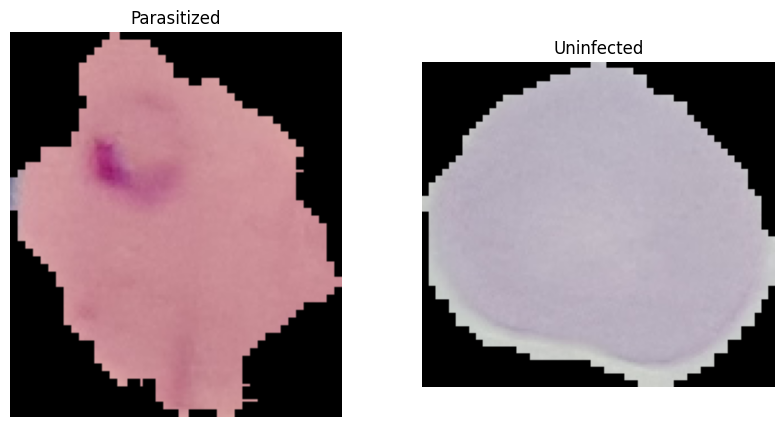

In [6]:
# Örnek görselleri gösteriyoruz

import matplotlib.pyplot as plt

import matplotlib.image as mpimg

infected_img = infected_path + "/" + os.listdir(infected_path)[0]

uninfected_img = uninfected_path + "/" + os.listdir(uninfected_path)[0]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(mpimg.imread(infected_img))

plt.title("Parasitized")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(mpimg.imread(uninfected_img))

plt.title("Uninfected")

plt.axis("off")

plt.show()

# Örnek görselleri gösteriyoruz

import matplotlib.pyplot as plt

import matplotlib.image as mpimg

infected_img = infected_path + "/" + os.listdir(infected_path)[0]

uninfected_img = uninfected_path + "/" + os.listdir(uninfected_path)[0]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(mpimg.imread(infected_img))

plt.title("Parasitized")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(mpimg.imread(uninfected_img))

plt.title("Uninfected")

plt.axis("off")

plt.show()

In [7]:
# Doğru ana klasörü seçiyoruz

base_path = dataset_path + "/cell_images/cell_images"

print(os.listdir(base_path))

['Uninfected', 'Parasitized']


In [8]:
# ImageDataGenerator oluşturuyoruz

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2
)

2026-05-17 12:07:21.052221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779019641.315722      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779019641.390972      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779019642.025643      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779019642.025706      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779019642.025716      16 computation_placer.cc:177] computation placer alr

In [9]:
# Train verisini oluşturuyoruz

train_data = datagen.flow_from_directory(
    base_path,
    target_size=(64,64),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 22048 images belonging to 2 classes.


In [10]:
# Validation verisini oluşturuyoruz

val_data = datagen.flow_from_directory(
    base_path,
    target_size=(64,64),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 5510 images belonging to 2 classes.


In [11]:
# Alt klasörleri detaylı kontrol ediyoruz

for item in os.listdir(base_path):
    print(item)

Uninfected
Parasitized


# 🧠 CNN Modeli

Bu bölümde Convolutional Neural Network modeli oluşturulacaktır.

In [12]:
# CNN katmanlarını oluşturuyoruz

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [13]:
# CNN modelini oluşturuyoruz

cnn = Sequential()

cnn.add(Conv2D(32, (3,3), activation="relu", input_shape=(64,64,3)))

cnn.add(MaxPooling2D(pool_size=(2,2)))

cnn.add(Conv2D(64, (3,3), activation="relu"))

cnn.add(MaxPooling2D(pool_size=(2,2)))

cnn.add(Flatten())

cnn.add(Dense(128, activation="relu"))

cnn.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-17 12:08:15.235561: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
# Model özetini inceliyoruz

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# CNN modelini derliyoruz

cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
# CNN modelini eğitiyoruz

history = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 204s 294ms/step - accuracy: 0.6581 - loss: 0.6063 - val_accuracy: 0.9232 - val_loss: 0.2161
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 96s 140ms/step - accuracy: 0.9306 - loss: 0.1986 - val_accuracy: 0.9309 - val_loss: 0.1976
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 95s 137ms/step - accuracy: 0.9546 - loss: 0.1347 - val_accuracy: 0.9334 - val_loss: 0.1761
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 95s 138ms/step - accuracy: 0.9627 - loss: 0.1109 - val_accuracy: 0.9323 - val_loss: 0.2038
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 96s 139ms/step - accuracy: 0.9732 - loss: 0.0804 - val_accuracy: 0.9327 - val_loss: 0.1947
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 94s 137ms/step - accuracy: 0.9776 - loss: 0.0645 - val_accuracy: 0.9281 - val_loss: 0.2216
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 96s 139ms/step - accuracy: 0.9860 - loss: 0.0434 - val_accuracy: 0.9328 - val_loss: 0.2523
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 97s 140ms/step - accuracy: 0.9906 - loss: 

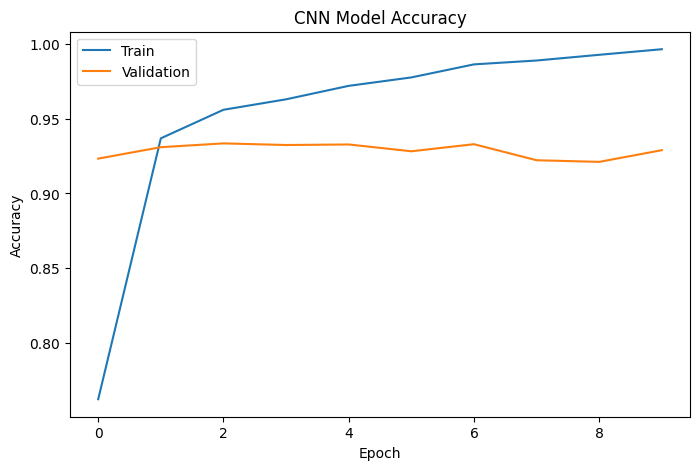

In [17]:
# Accuracy değişimini görselleştiriyoruz

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("CNN Model Accuracy")

plt.ylabel("Accuracy")

plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

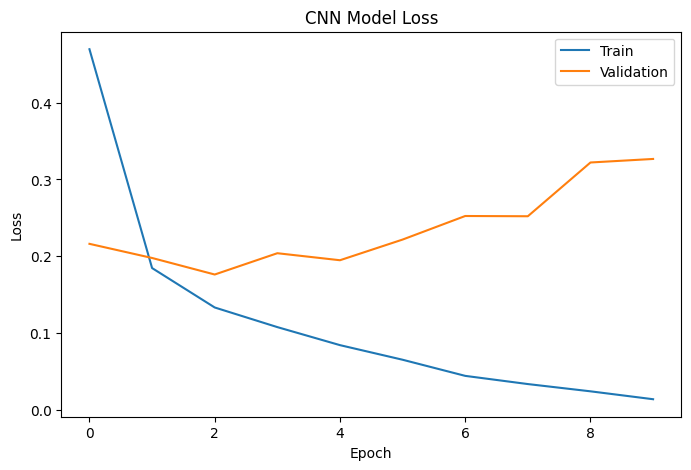

In [18]:
# Loss değişimini görselleştiriyoruz

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("CNN Model Loss")

plt.ylabel("Loss")

plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])

plt.show()

# 📌 Proje Sonucu

Bu projede CNN (Convolutional Neural Network) modeli kullanılarak malaria hücre görüntüleri sınıflandırılmıştır.

Model:
- Parasitized
- Uninfected

olmak üzere iki sınıf üzerinde eğitilmiştir.

Sonuç olarak model yaklaşık %93 validation accuracy başarısı göstermiştir.

Bu proje kapsamında:
- Image preprocessing
- ImageDataGenerator
- CNN mimarisi
- Conv2D
- MaxPooling
- Flatten
- Dense katmanları
- Deep Learning image classification

uygulanmıştır.